In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/binary-classification-with-a-bank-dataset-clone/sample_submission.csv
/kaggle/input/binary-classification-with-a-bank-dataset-clone/train.csv
/kaggle/input/binary-classification-with-a-bank-dataset-clone/test.csv


In [30]:
train_data = pd.read_csv("/kaggle/input/binary-classification-with-a-bank-dataset-clone/train.csv")
train_data.head()
test_data = pd.read_csv("/kaggle/input/binary-classification-with-a-bank-dataset-clone/test.csv")

In [31]:
train_data.info()
train_data['y'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


y
0    659512
1     90488
Name: count, dtype: int64

In [32]:
train_data['y'].value_counts(dropna=False)



y
0    659512
1     90488
Name: count, dtype: int64

In [33]:
from sklearn.model_selection import train_test_split

X = train_data.drop(columns=["y"])
y = train_data["y"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [34]:
full = pd.concat([X_train, X_val], axis=0)
full = pd.get_dummies(full)

X_train_enc = full.iloc[:len(X_train)]
X_val_enc = full.iloc[len(X_train):]


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs=-1
)
rf.fit(X_train_enc, y_train)


y_proba_rf = rf.predict_proba(X_val_enc)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.9621666431775555


In [40]:
X_full = train_data.drop(columns=["y"])
y_full = train_data["y"]

X_kaggle_test = test_data.drop(columns=["id"])


full = pd.concat([X_full, X_kaggle_test], axis=0)
full = pd.get_dummies(full)


X_full_enc = full.iloc[:len(X_full)]
X_test_enc = full.iloc[len(X_full):]


In [42]:
rf.fit(X_full_enc, y_full)

y_pred = rf.predict_proba(X_test_enc)[:, 1]


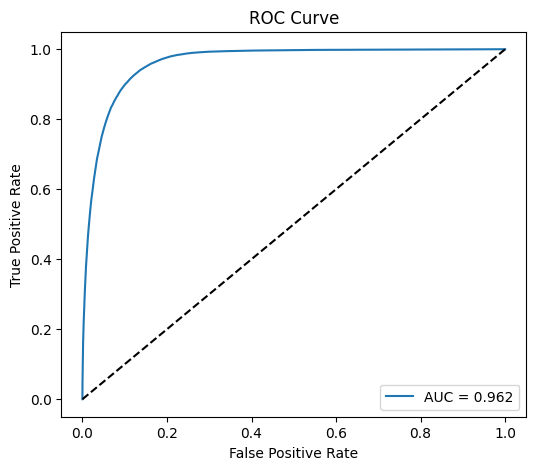

In [43]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [44]:
y_pred = rf.predict_proba(X_test_enc)[:, 1]


In [47]:
submission = pd.DataFrame({
    "id": test_data["id"],
    "y": y_pred
})

submission.to_csv("submission.csv", index=False)
